<a href="https://colab.research.google.com/github/Aishwaryaselvaraju/CODSOFT/blob/main/Codsoft_Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project:** Iris Flower Classification using Machine Learning

**Dataset Source:** Iris Dataset ( Kaggle)

**Description:** This project classifies iris flowers into three species **Setosa, Versicolor, and Virginica** using their physical measurements such as sepal length, sepal width, petal length, and petal width. The model learns from these features to predict the species of a given flower accurately.

**Tools Used:** Python, Pandas, NumPy, Seaborn, Matplotlib, Scikit-Learn, Joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IRIS.csv to IRIS.csv


In [ ]:
# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].apply(lambda x: iris.target_names[x])

print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


## Pairplot to visualize data

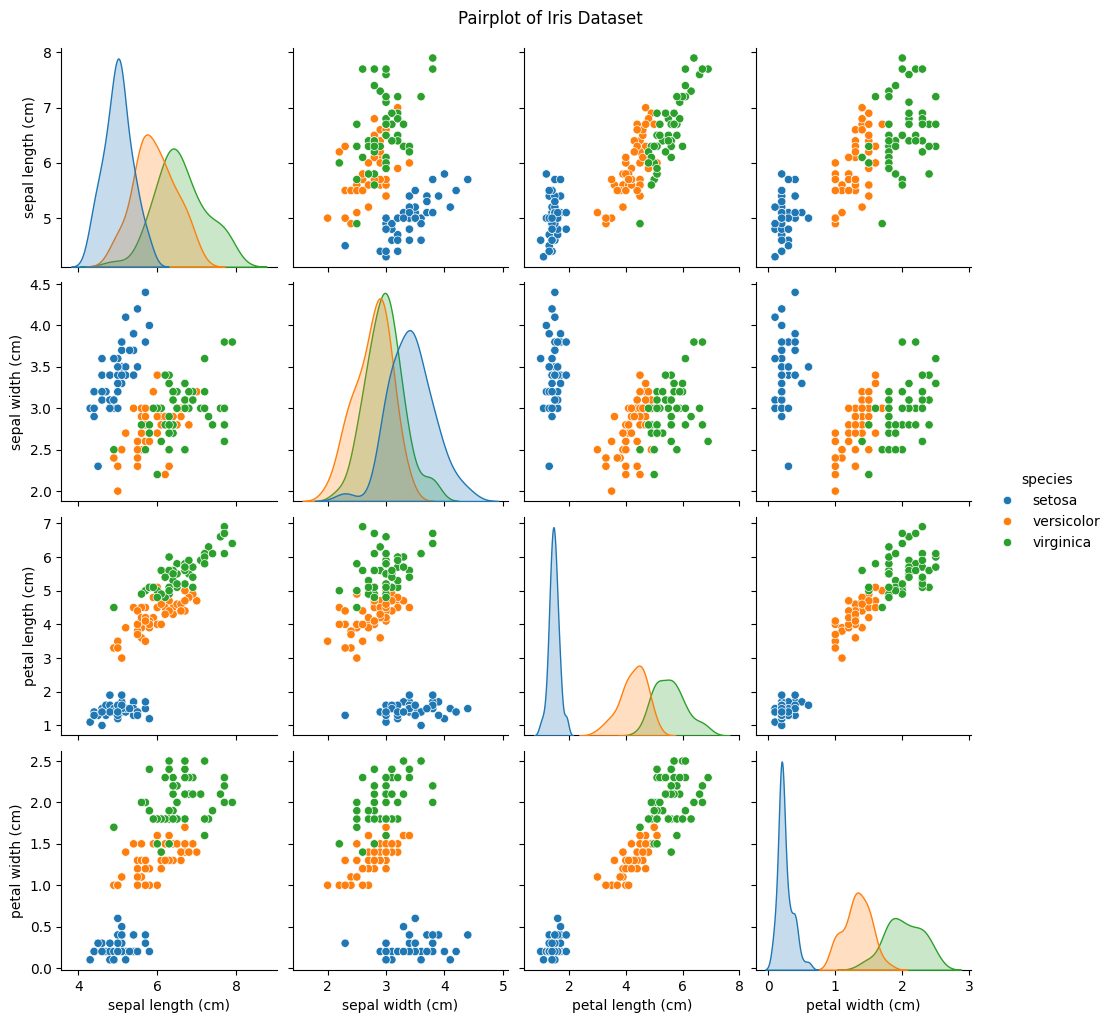

In [ ]:

sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle("Pairplot of Iris Dataset", y=1.02)
plt.show()



## Heatmap of feature correlation

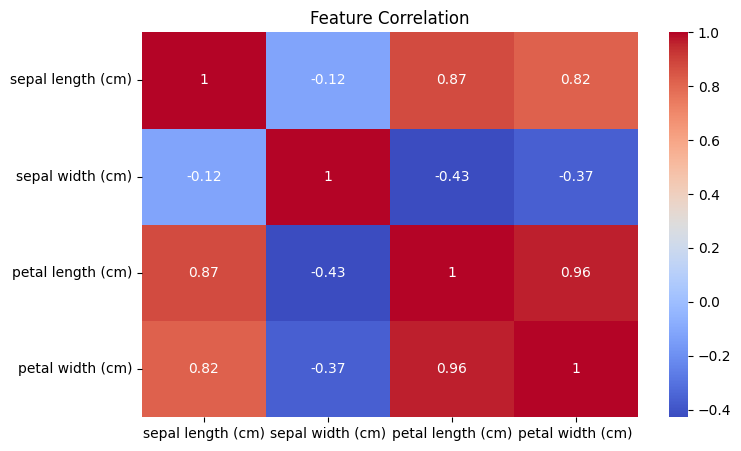

In [ ]:

plt.figure(figsize=(8,5))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Countplot of Each Species

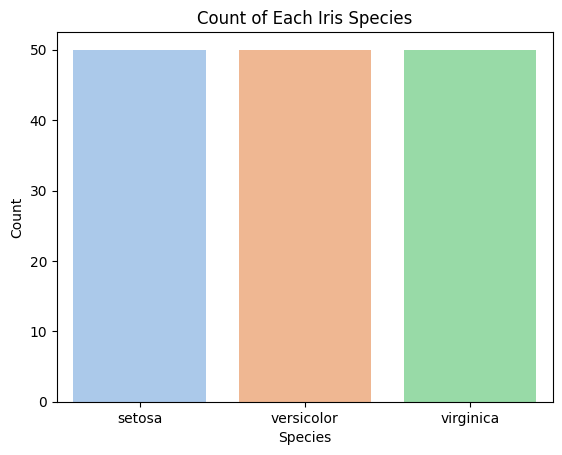

In [ ]:
sns.countplot(x='species', data=df, hue='species', palette='pastel', dodge=False, legend=False)
plt.title("Count of Each Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()


# Histogram for Each Feature

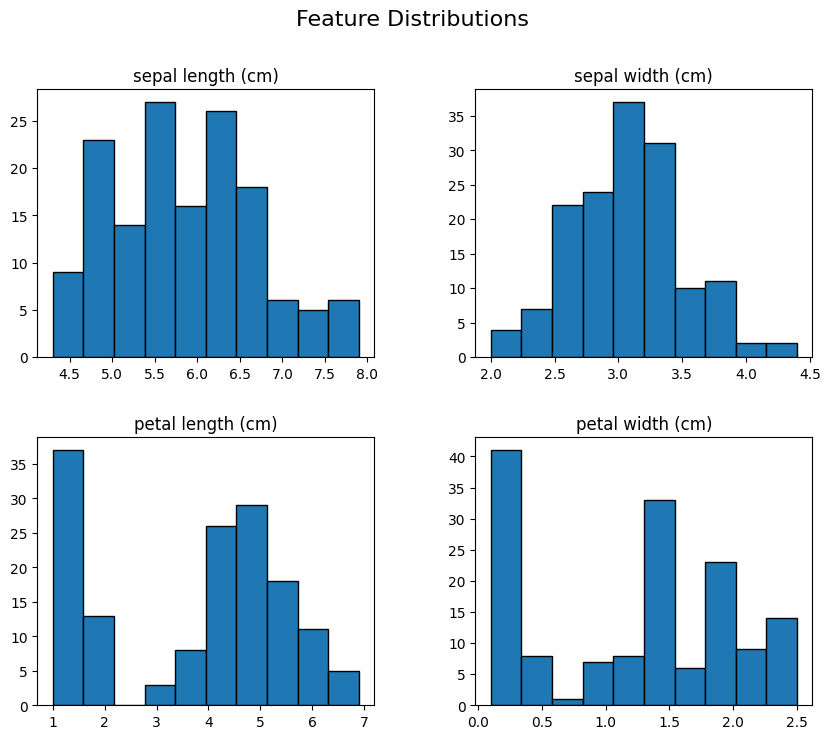

In [ ]:
df.hist(figsize=(10,8), edgecolor='black', grid=False)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


# Box Plot for All Features

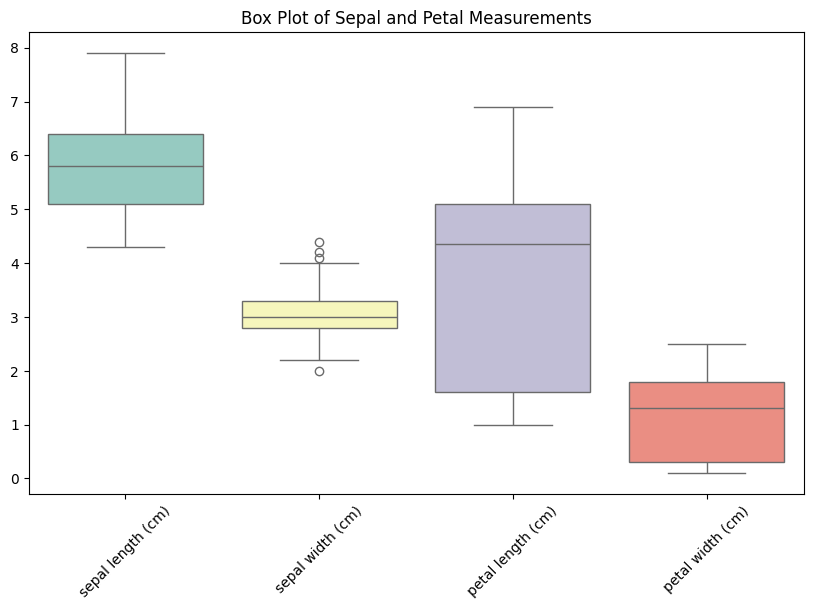

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.iloc[:,:-1], palette='Set3')
plt.title("Box Plot of Sepal and Petal Measurements")
plt.xticks(rotation=45)
plt.show()


# Violin Plot by Species

/tmp/ipython-input-9-1966192673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="species", y="petal length (cm)", data=df, palette='coolwarm')


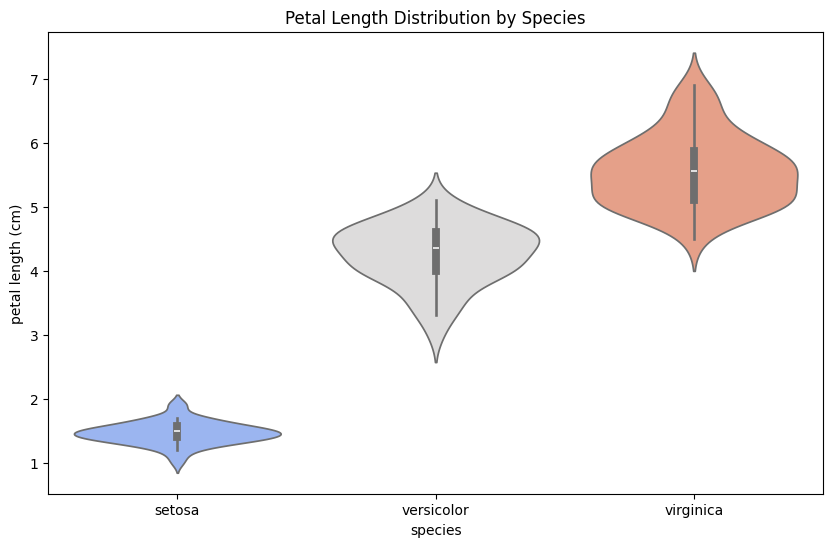

In [ ]:
plt.figure(figsize=(10,6))
sns.violinplot(x="species", y="petal length (cm)", data=df, palette='coolwarm')
plt.title("Petal Length Distribution by Species")
plt.show()

# Swarm Plot

/tmp/ipython-input-10-1218445416.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='species', y='sepal width (cm)', data=df, palette='Set2')


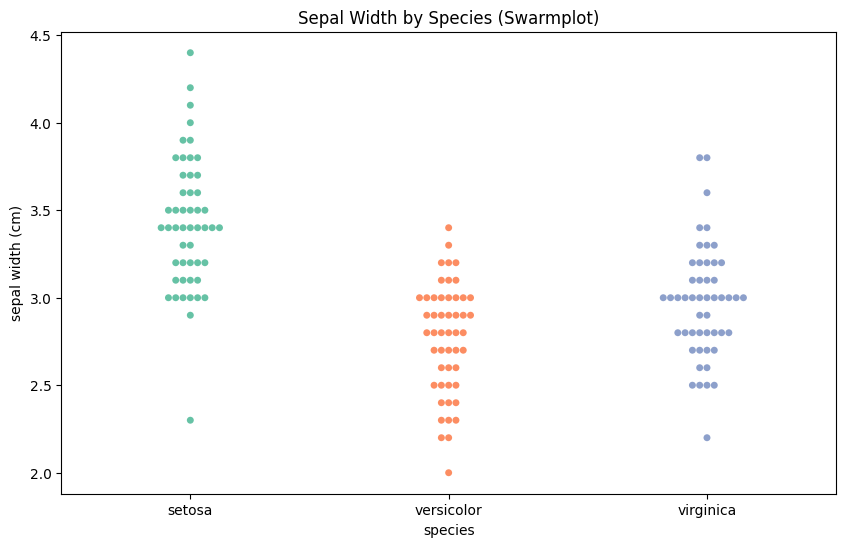

In [ ]:
plt.figure(figsize=(10,6))
sns.swarmplot(x='species', y='sepal width (cm)', data=df, palette='Set2')
plt.title("Sepal Width by Species (Swarmplot)")
plt.show()

# Jointplot (Scatter + Histogram)

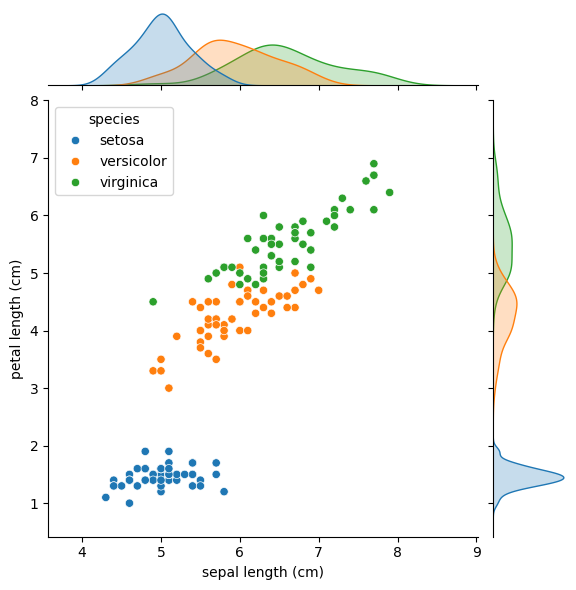

In [ ]:
sns.jointplot(data=df, x='sepal length (cm)', y='petal length (cm)', hue='species')
plt.show()


# 3D Scatter Plot

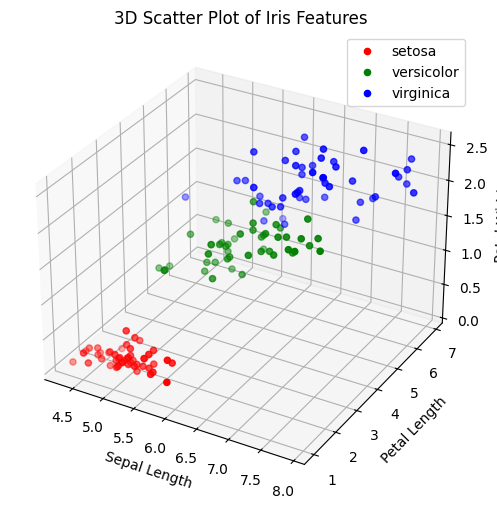

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

colors = {'setosa': 'r', 'versicolor': 'g', 'virginica': 'b'}

for species in df['species'].unique():
    subset = df[df['species'] == species]
    ax.scatter(subset['sepal length (cm)'], subset['petal length (cm)'], subset['petal width (cm)'],
               label=species, c=colors[species])

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Petal Length")
ax.set_zlabel("Petal Width")
ax.set_title("3D Scatter Plot of Iris Features")
ax.legend()
plt.show()


In [ ]:
X = df.iloc[:, :-1]  # Features
y = df['species']    # Labels

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Accuracy Score: 1.0

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



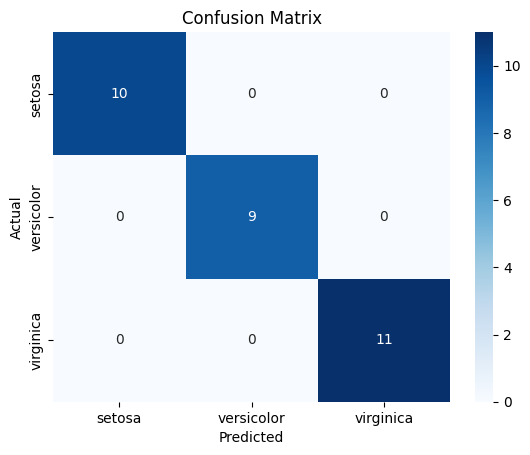

In [ ]:
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression()
}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.2f}")


Random Forest Accuracy: 1.00
SVM Accuracy: 1.00
K-Nearest Neighbors Accuracy: 1.00
Logistic Regression Accuracy: 1.00


In [ ]:
x_labels = list(models.keys())

plt.figure(figsize=(8,5))
sns.barplot(x=x_labels, y=accuracy_scores, hue=x_labels, palette='Set2', dodge=False, legend=False)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.show()



NameError: name 'accuracy_scores' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
import joblib
joblib.dump(model, 'iris_classifier_model.pkl')

# To load the model later
# model = joblib.load('iris_classifier_model.pkl')


['iris_classifier_model.pkl']